# *Importation of libraries and yolo model*

In [ ]:
%pip install ultralytics
from ultralytics import YOLO, checks, hub
checks()

Ultralytics 8.3.83 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 35.5/235.7 GB disk)


In [ ]:
import os
import glob
import numpy as np
from IPython import display
from IPython.display import Image, display_html
from IPython.display import Image, display
!yolo mode=checks
from google.colab import drive
drive.mount('/content/drive')

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/cfg/__init__.py", line 919, in entrypoint
    raise ValueError(f"Invalid 'mode={mode}'. Valid modes are {MODES}.\n{CLI_HELP_MSG}")
ValueError: Invalid 'mode=<module 'ultralytics.utils.checks' from '/usr/local/lib/python3.11/dist-packages/ultralytics/utils/checks.py'>'. Valid modes are frozenset({'train', 'predict', 'export', 'benchmark', 'val', 'track'}).

    Arguments received: ['yolo', 'mode=checks']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of frozenset({'detect', 'obb', 'classify', 'segment', 'pose'})
                MODE (required) is one of frozenset({'train', 'predict', 'export', 'benchmark', 'val', 'track'})
                ARGS (optional) are any number of custom 'arg=value' pairs like 'imgsz=320' tha

# *Training the model with the best weights*

In [ ]:
!yolo task=detect mode=train model='/content/drive/MyDrive/YOLOv8x/best.pt' data='/content/drive/MyDrive/detect/detect/detect.yaml' epochs=20 imgsz=640 augment=True patience=10

Ultralytics 8.3.83 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/YOLOv8x/best.pt, data=/content/drive/MyDrive/detect/detect/detect.yaml, epochs=20, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, 

## *Confusion matrix*

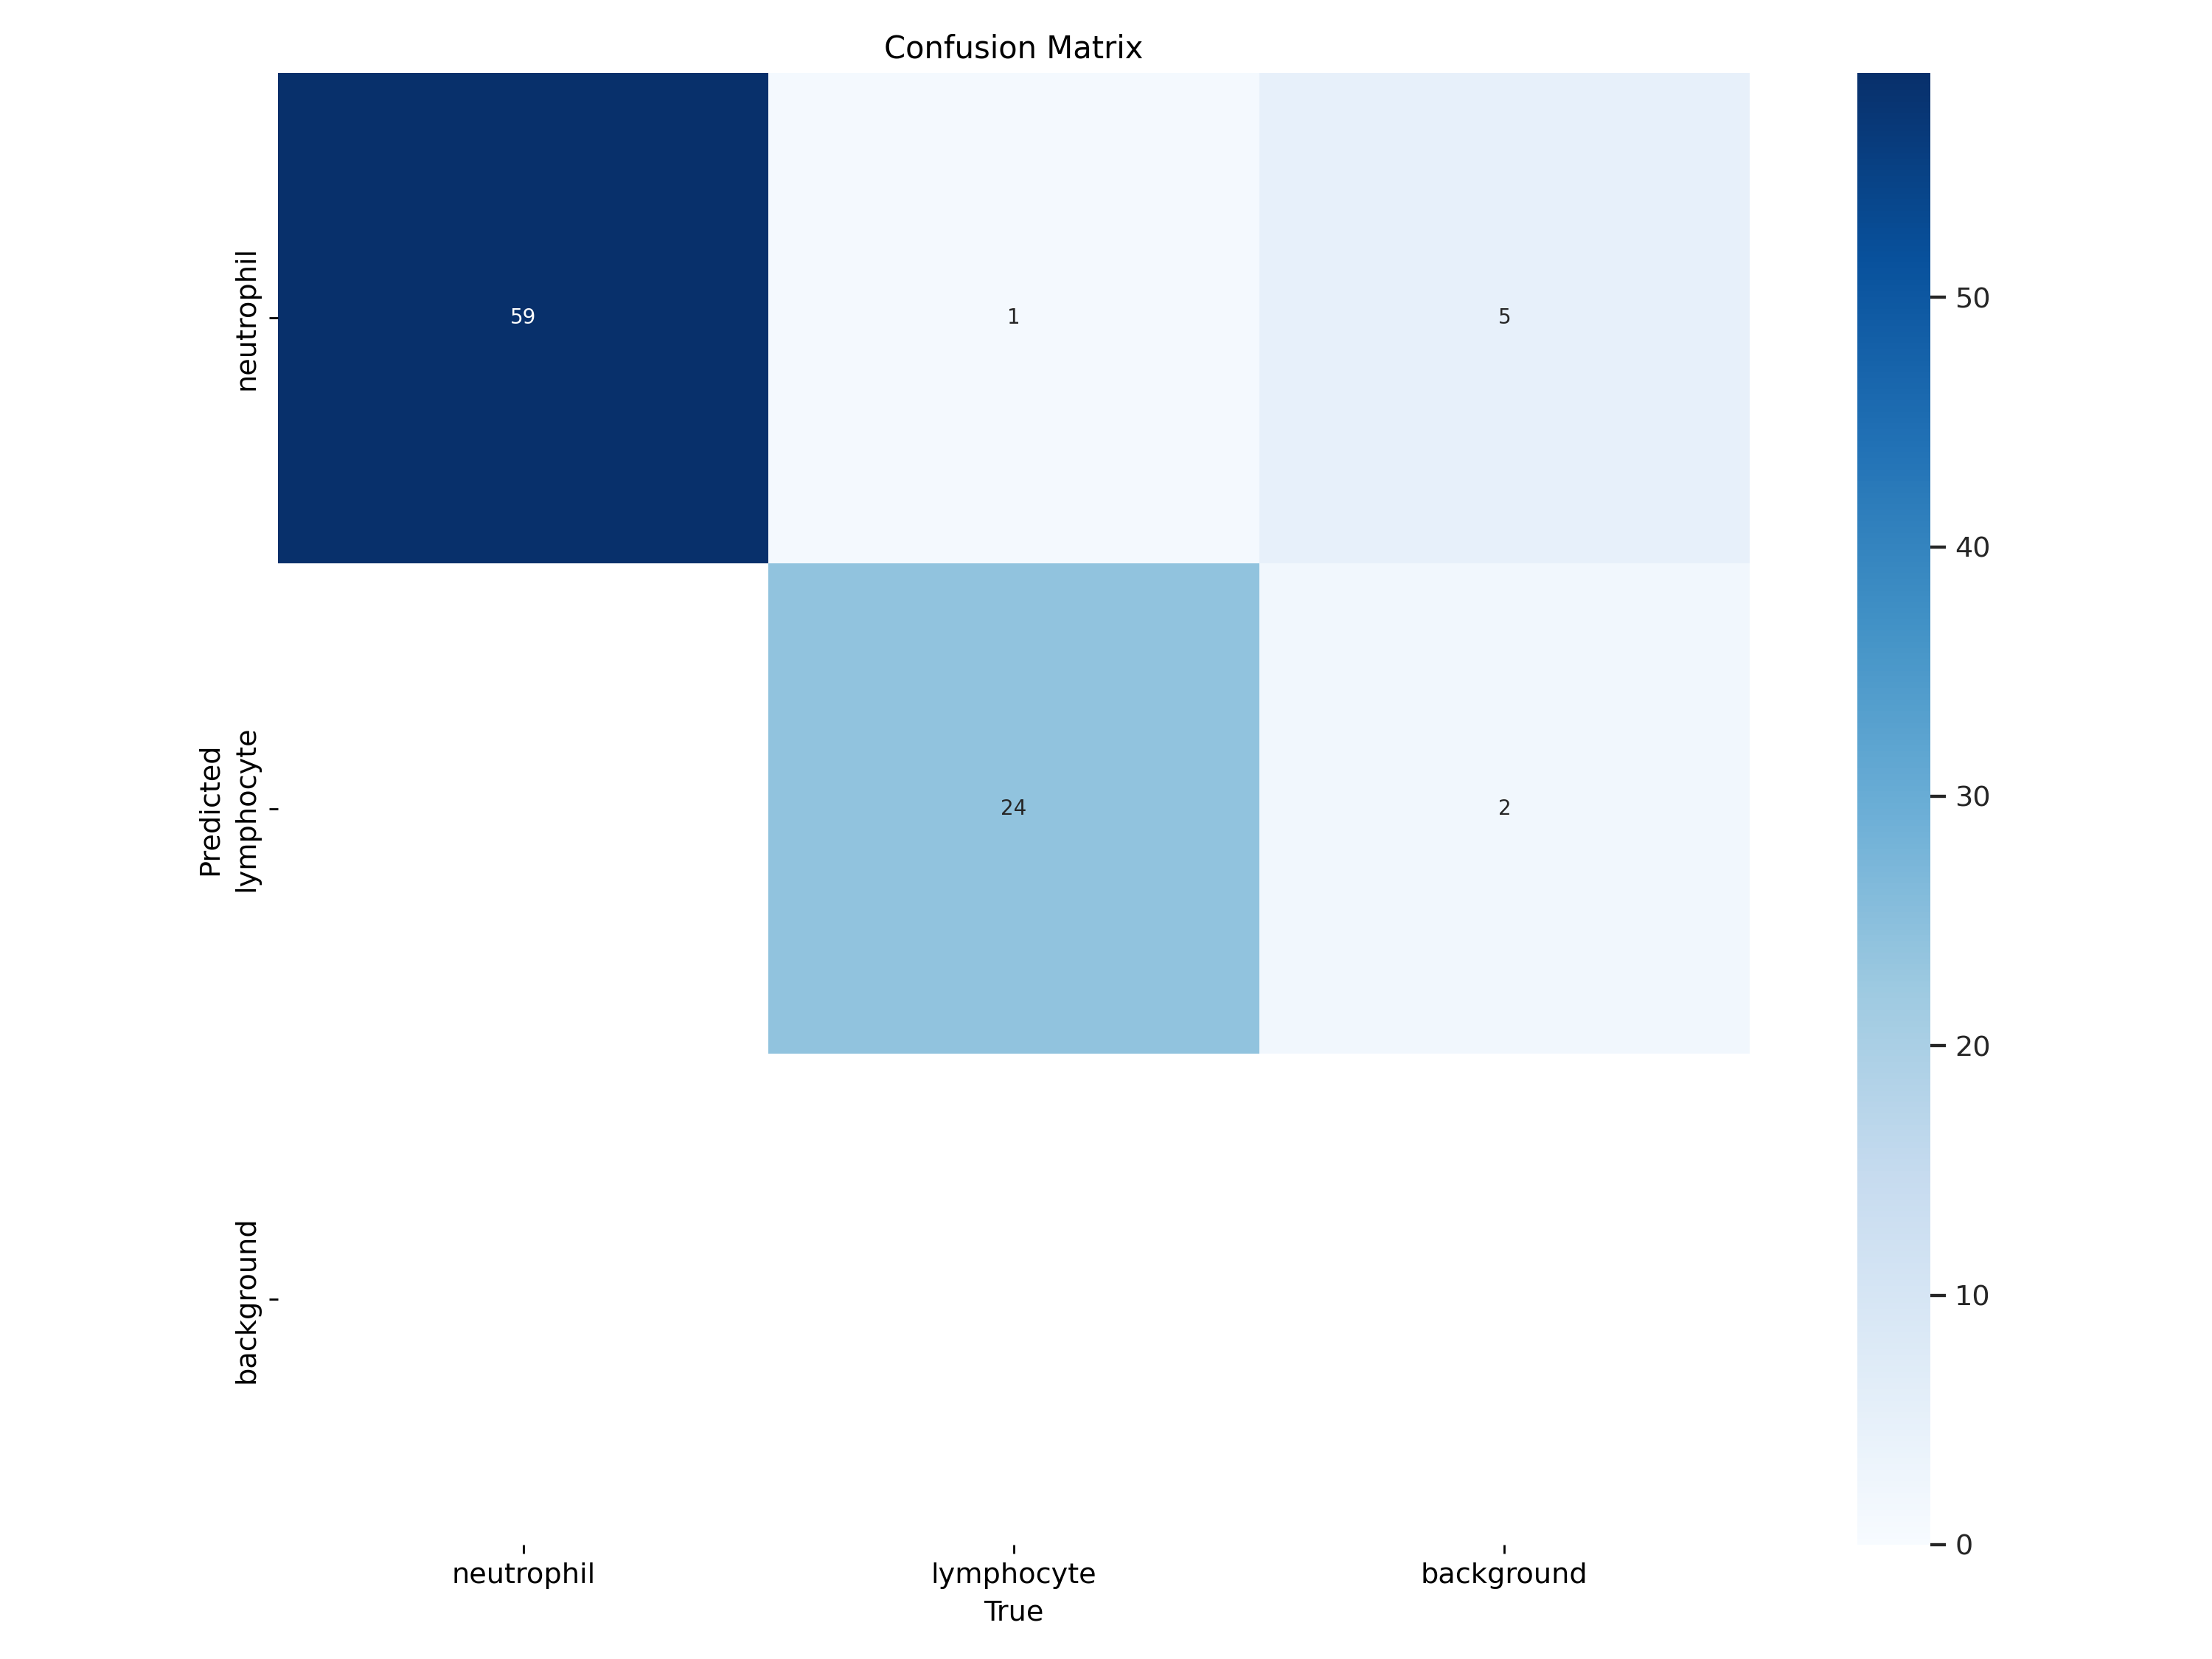

In [ ]:
Image(filename = f'/content/runs/detect/train/confusion_matrix.png', width=800)

## *Results*

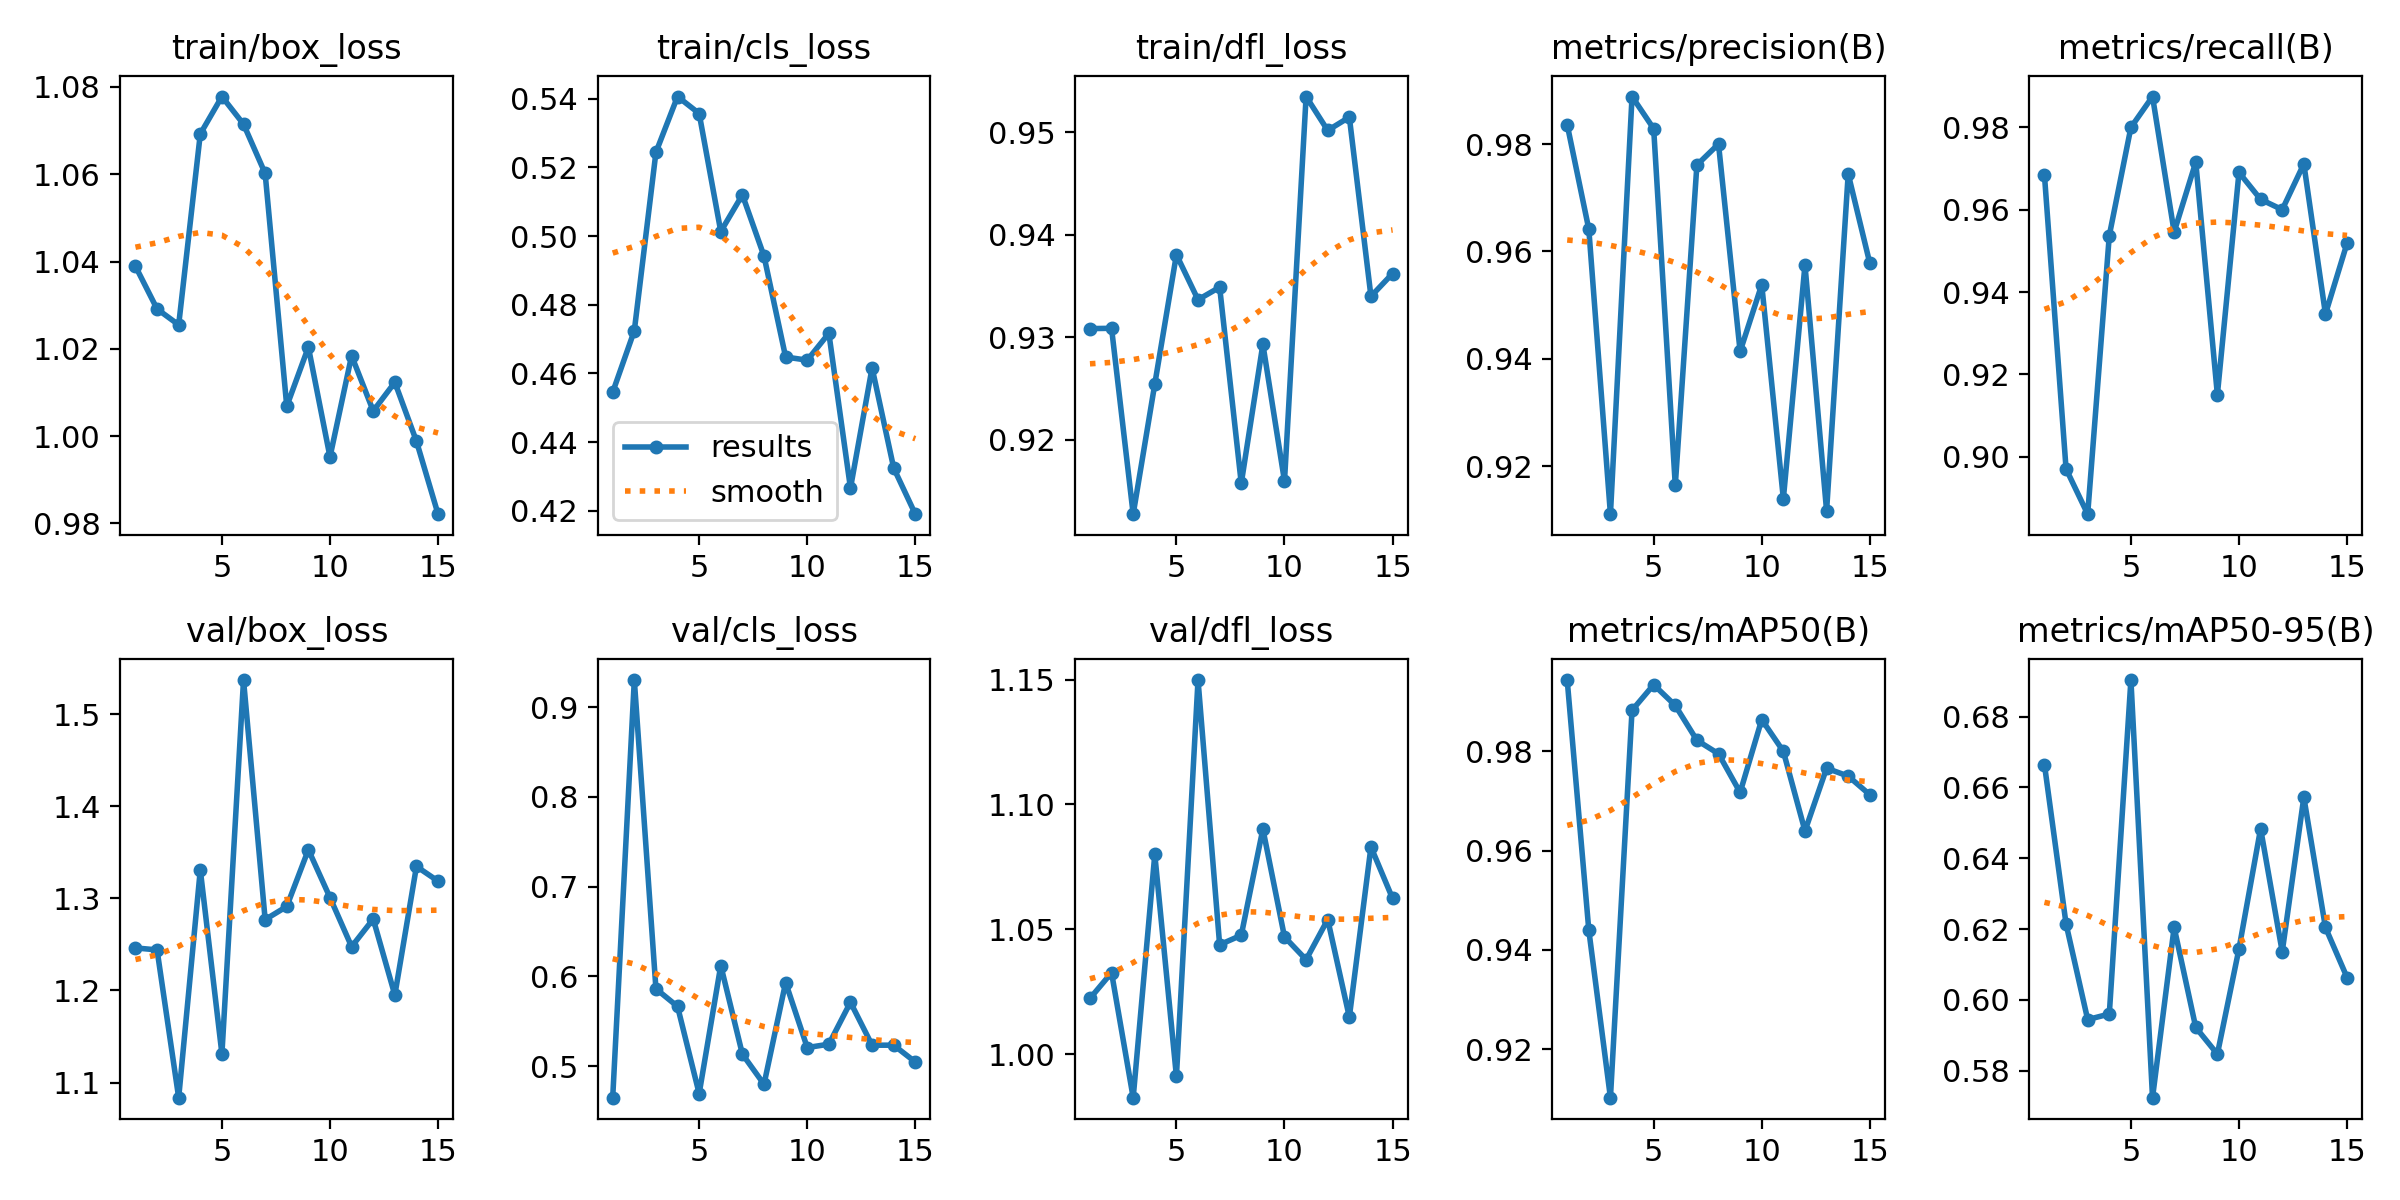

In [ ]:
Image(filename = f'/content/runs/detect/train/results.png', width=800)

# *Model validation*

In [ ]:
!yolo task=detect mode=val model= '/content/runs/detect/train/weights/best.pt' data='/content/drive/MyDrive/detect/detect/detect.yaml'

Ultralytics 8.3.83 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 112 layers, 68,125,494 parameters, 0 gradients, 257.4 GFLOPs
val: Scanning /content/drive/MyDrive/detect/detect/labels/val.cache... 76 images, 0 backgrounds, 0 corrupt: 100% 76/76 [00:00<?, ?it/s]
val: WARNING ⚠️ /content/drive/MyDrive/detect/detect/images/val/727.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/drive/MyDrive/detect/detect/images/val/728.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/drive/MyDrive/detect/detect/images/val/819.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/drive/MyDrive/detect/detect/images/val/820.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/drive/MyDrive/detect/detect/images/val/821.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/drive/MyDrive/detect/detect/images/val/822.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/drive/MyDrive/detect/detect/im

# *Testing the model*

In [ ]:
!yolo task=detect mode=predict model= '/content/runs/detect/train/weights/best.pt' conf=0.5 source='/content/drive/MyDrive/detect/detect/images/test' save=True save_txt=True project='/content/drive/MyDrive/detect/results' name='test_predictions'

Ultralytics 8.3.83 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 112 layers, 68,125,494 parameters, 0 gradients, 257.4 GFLOPs

image 1/76 /content/drive/MyDrive/detect/detect/images/test/729.jpg: 288x640 1 neutrophil, 54.6ms
image 2/76 /content/drive/MyDrive/detect/detect/images/test/730.jpg: 288x640 1 neutrophil, 11.7ms
image 3/76 /content/drive/MyDrive/detect/detect/images/test/731.jpg: 288x640 1 neutrophil, 11.8ms
image 4/76 /content/drive/MyDrive/detect/detect/images/test/732.jpg: 288x640 1 neutrophil, 11.7ms
image 5/76 /content/drive/MyDrive/detect/detect/images/test/733.jpg: 288x640 1 neutrophil, 12.1ms
image 6/76 /content/drive/MyDrive/detect/detect/images/test/734.jpg: 288x640 1 neutrophil, 11.8ms
image 7/76 /content/drive/MyDrive/detect/detect/images/test/735.jpg: 288x640 1 lymphocyte, 11.8ms
image 8/76 /content/drive/MyDrive/detect/detect/images/test/736.jpg: 288x640 1 neutrophil, 12.2ms
image 9/76 /content/drive/MyDrive/de

# *Testing metrics based on leukocyte count*

In [ ]:
def get_predictions(prediction_dir):
    predictions = {}
    for filename in os.listdir(prediction_dir):
        if filename.endswith(".txt"):
            with open(os.path.join(prediction_dir, filename), "r") as file:
                predictions[filename] = len(file.readlines())

    return predictions

def get_ground_truth(ground_truth_dir):
    ground_truth = {}
    for filename in os.listdir(ground_truth_dir):
        if filename.endswith(".txt"):
            with open(os.path.join(ground_truth_dir, filename), "r") as file:
                ground_truth[filename] = len(file.readlines())
    return ground_truth

In [ ]:
prediction_dir = "/content/drive/MyDrive/detect/results/test_predictions/labels"
ground_truth_dir = "/content/drive/MyDrive/detect/detect/labels/test"

predictions = get_predictions(prediction_dir)
ground_truth = get_ground_truth(ground_truth_dir)
y_pred = []
y_true = []

for filename in ground_truth:
    if filename in predictions:
        y_true.append(ground_truth[filename])
        y_pred.append(predictions[filename])

y_true = np.array(y_true)
y_pred = np.array(y_pred)

TP = np.sum((y_pred == y_true) & (y_true > 0))
TN = 0
FP = np.sum((y_pred != y_true) & (y_pred > 0))
FN = np.sum((y_pred != y_true) & (y_true > 0))

print(f"Verdaderos Positivos (TP): {TP}")
print(f"Falsos Positivos (FP): {FP}")
print(f"Falsos Negativos (FN): {FN}")

Verdaderos Positivos (TP): 72
Falsos Positivos (FP): 2
Falsos Negativos (FN): 2


In [ ]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP/(TP + FP)
recall = TP/(TP + FN)
f1 = 2/((1/precision) + (1/recall))

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9473684210526315
Precision: 0.972972972972973
Recall: 0.972972972972973
F1 Score: 0.972972972972973


AUC-ROC: 1.0


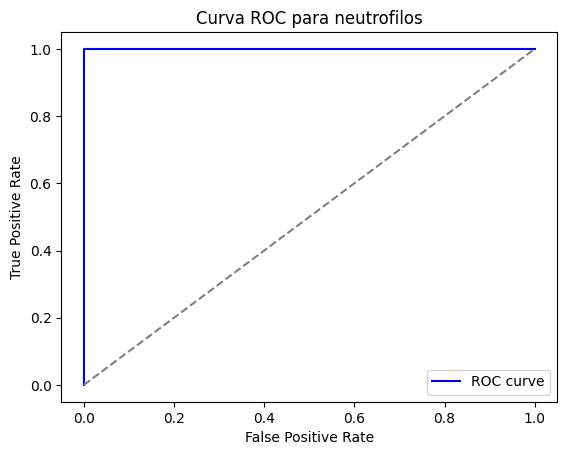

In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

y_true_n = np.array([1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
                   1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                   1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
                   1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
                   0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
                   1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
                   0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
                   0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
                   1, 1, 0, 1, 1, 1])
y_pred_n = np.array([0.83, 0.84, 0.84, 0.81, 0.85, 0.82, 0.22, 0.84, 0.28, 0.84,
                   0.83, 0.83, 0.84, 0.79, 0.81, 0.81, 0.83, 0.84, 0.27, 0.29,
                   0.85, 0.84, 0.85, 0.83, 0.83, 0.87, 0.86, 0.81, 0.86, 0.82,
                   0.80, 0.82, 0.82, 0.79, 0.76, 0.85, 0.83, 0.84, 0.84, 0.82,
                   0.29, 0.23, 0.86, 0.81, 0.83, 0.27, 0.85, 0.84, 0.83, 0.80,
                   0.82, 0.83, 0.83, 0.81, 0.84, 0.78, 0.79, 0.76, 0.80, 0.23,
                   0.29, 0.83, 0.29, 0.83, 0.23, 0.81, 0.24, 0.50, 0.38, 0.84,
                   0.35, 0.39, 0.36, 0.74, 0.83, 0.77, 0.85, 0.79, 0.80, 0.81,
                   0.79, 0.81, 0.56, 0.83, 0.85, 0.83])
auc_n = roc_auc_score(y_true_n, y_pred_n)
print(f'AUC-ROC: {auc_n}')

fpr, tpr, _ = roc_curve(y_true_n, y_pred_n)
plt.plot(fpr, tpr, color='blue', label='ROC curve')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC para neutrofilos')
plt.legend(loc='best')
plt.show()

AUC-ROC: 0.8500000000000001


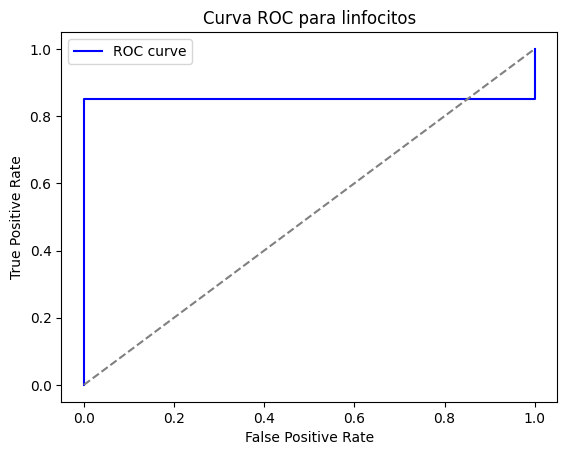

In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

y_true_l = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
                   1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
                   1, 1, 1, 0, 0, 1, 0, 0, 1, 0,
                   0, 0, 0, 1, 0, 0, 0, 0])
y_pred_l = np.array([0.17, 0.16, 0.16, 0.19, 0.15, 0.18, 0.78, 0.16, 0.72, 0.16,
                   0.17, 0.17, 0.16, 0.21, 0.19, 0.19, 0.17, 0.16, 0.73, 0.71,
                   0.15, 0.16, 0.15, 0.17, 0.17, 0.13, 0.14, 0.19, 0.14, 0.18,
                   0.20, 0.18, 0.18, 0.21, 0.24, 0.15, 0.17, 0.16, 0.16, 0.18,
                   0.71, 0.77, 0.14, 0.19, 0.17, 0.73, 0.15, 0.16, 0.17, 0.20,
                   0.18, 0.17, 0.17, 0.19, 0.16, 0.22, 0.21, 0.24, 0.20, 0.77,
                   0.71, 0.17, 0.71, 0.17, 0.77, 0.19, 0.76, 0.50, 0.62, 0.16,
                   0.65, 0.61, 0.64, 0.26, 0.17, 0.0,  0.23, 0.15, 0.0,  0.21,
                   0.20, 0.19, 0.21, 0.0, 0.19, 0.17, 0.15, 0.17])
auc_l = roc_auc_score(y_true_l.ravel(), y_pred_l.ravel())
print(f'AUC-ROC: {auc_l}')

fpr, tpr, _ = roc_curve(y_true_l, y_pred_l)
plt.plot(fpr, tpr, color='blue', label='ROC curve')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC para linfocitos')
plt.legend(loc='best')
plt.show()

In [ ]:
average_auc_roc = (auc_n + auc_l) / 2
print(f"Promedio de AUC-ROC: {average_auc_roc}")

Promedio de AUC-ROC: 0.925
